In [2]:
#| output: false

from Scripts import dicko
from Scripts import goncalves

goncalves_est = goncalves.get_estimates('../Data_Fitting/Goncalves/goncalves1_draws.csv')


# Model details

To develop and calibrate a model of SMC we used the data from @chandramohan_seasonal_2021 and @dicko_seasonal_2024. This phase 3 trial followed almost 6,000 children from 5-17 months until 3 years of age [@chandramohan_seasonal_2021], and just over 5,000 of these children for another two years [@dicko_seasonal_2024] in two seasonal sites: Bougouni district in Mali and Hounde district, Burkina Faso. Children were enrolled into one of three treatment cohorts: SMC-only, RTS,S-only and SMC+RTS,S combined. There was no cohort that had no interventions because SMC is the standard of care in Burkina Faso and Mali.

The primary trial endpoint was the incidence of clinical malaria, defined as a temperature of at least 37.5°C, or a history of fever within the past 48 h, and parasitaemia greater than 5000 parasites/µl, in children who presented at a health facility.

Coverage for RTS,S remained high at about 95% throughout the study. Coverage for SMC increased gradually from about 83% in year 1 to about 95% in year 5.

Clinical case definition was fever and more than 5000 parasites/µl. Our analysis of the @goncalves_parasite_2014 data suggest `{python} f'{goncalves_est.P_fever_and_5000.mean():.0%}'` of blood infections meet this case definition. For the model we need to supply the parameter `episode_def_clinical` which is 

$$
\text{Pr}(\ge 5000\ \text{parasites/μl}\ |\ \text{fever}) = \frac{\text{Pr}(\ge 5000\ \text{parasites/μl and fever})}{\text{Pr}(\text{fever})}
$$

Given that $\text{Pr}(\text{fever})=$ `{python} f'{goncalves_est.P_fever.mean():.0%}'` we have $\text{Pr}(\ge 5000\ \text{parasites/μl}\ |\ \text{fever})=$ `{python} f'{goncalves_est.P_fever_and_5000.mean()/goncalves_est.P_fever.mean():.0%}'`.

The timing and strength of the malaria season was calibrated against the clinical data.

We used Imperial's RTS,S vaccine protection profile with no modification (@penny_public_2016, Table S2.2). It's timing relative to the malaria season was calibrated against the clinical data. 

We assume that children who have been given SMC are at less risk of a blood infection. This will delay their development of naturally acquired immunity. Our initial model of the SMC protection profile was quite complicated: We assumed that all children were given SMC in the same weeks and had identical protection profiles. We assumed that the protective profile of SMC waned with some decay rate between monthly rounds and the protective profile after the fourth round decayed at this same rate. This model did not adequately fit the data.

On reflection, this model of SMC delivery and protection is appropriate for individual-based-models in which heterogeneities can be explicitly incorporated, such as heterogeneities in when SMC is taken, and heterogeneities in reduced risk of infection. This level of modelling comes at a cost though because these heterogeneities need to be modelled using probability distributions and there is often little or no data available to parametrise them.

Our model, on the other hand, is population-based. We model the average effect of SMC at the level of the population. Thus heterogeneities are implicit; they are averaged across the population and smoothed out over time. For example, heterogeneity in when a round of SMC is taken by a cohort of children is smoothed out over the course of a following month resulting in a flatter protective profile experienced at the population level rather than a saw-tooth profile experienced by an individual child.

We therefore simplified our model so that the protective profile ramps up, at some given rate, until it plateaus at some given coverage. It stays at this level until the end of four rounds (four months) at which point it returns to zero. We use a coverage of 90% (the average over the 5 trial years). We calibrated the timing of the first round of SMC and the rate of ramping up against the clinical data.


# Calibration with clinical data

The model parameters we calibrated were the blood infection rate, the strength and timing of the malaria season, the timings of administration of RTS,S and SMC relative to the malaria season and the rate of ramping-up of SMC protection. All other parameters were derived from the existing malaria epidemiological, trial and modelling literature. We calibrated these parameters by simply minimising the sum of the absolute difference in observed and predicted clinical episodes in all three cohorts over the whole five years using the Nelder-Mead method of the minimize algorithm of scipy V1.13.0.

In [3]:
#| output: false

estimates = dicko.dicko_clinical_episode_calibration()

Parameter values that minimise the sum of the absolute differences between observed and predicted clinical cases
  season_peak = 26
  season_width = 0.1
  offset_liver = 16
  smc_ramp = 0.24
  smc_offset = 14
  smc_rounds = 4
  λ = 2


# Prediction of clinical episodes

The output of the calibrated model is shown in @fig-dicko-clinical-case-prediction with clinical episode data from @dicko_seasonal_2024 shown as circles. Note that the data are pooled from the two sites.

Panel D shows the seasonality in infection rate (thin red line, scaled to a maximum of 1) and the protective profiles of RTS,S (green) and SMC (blue). The calibration predicted that RTS,S and SMC were both deployed at the start of the malaria season as expected, and SMC was stopped prior to the end of the season.

The model captures the temporal dynamics of the RTS,S-only cohort (panel A) very well with the peaks rising from year to year due to the waning of early-life protection. The higher peak in the fifth year is presumably due to a more intense malaria season — although no reason was given in the paper.

The model predicts two peaks in clinical episodes each season for SMC-only (panel B), and this can also be seen in the data. The first peak occurs at the peak of the malaria season. The second peak occurs because SMC stops being given to children before the end of the malaria season. As the protective effect of SMC is short-lived, clinical episodes rise at the end of the season to match the natural force of infection. @dicko_seasonal_2024 noted that the low incidence of malaria in all cohorts in the first year was probably due to much lower than average rainfall in that year and the young age of the study children at that time. As we do not model rainfall, or its effects, on transmission intensity this probably explains why we predict a second peak where the data shows none. But we do model early-life protection which is predicted to reduce clinical episodes. We also do not capture the height of the second peak at the end of the fifth year. This is probably because children in Burkina Faso had five rounds of SMC rather than the usual four (again we do not model this).

The model also predicts the scale and temporal dynamics of the combined RTS,S+SMC treatment well (panel C), with the same caveats as for the SMC-only cohort.

Treatment efficacy of cumulative clinical episodes of combined vs. RTS,S-only (green) and SMC-only (blue) are shown in panel E. We predict little change in efficacy over the full five years as the data suggest. We under-estimate efficacy though. This is due to our over-estimate of episodes in the combined treatment in year 1. As noted above this over-estimation is because we do not model rainfall effects on transmission intensity. 

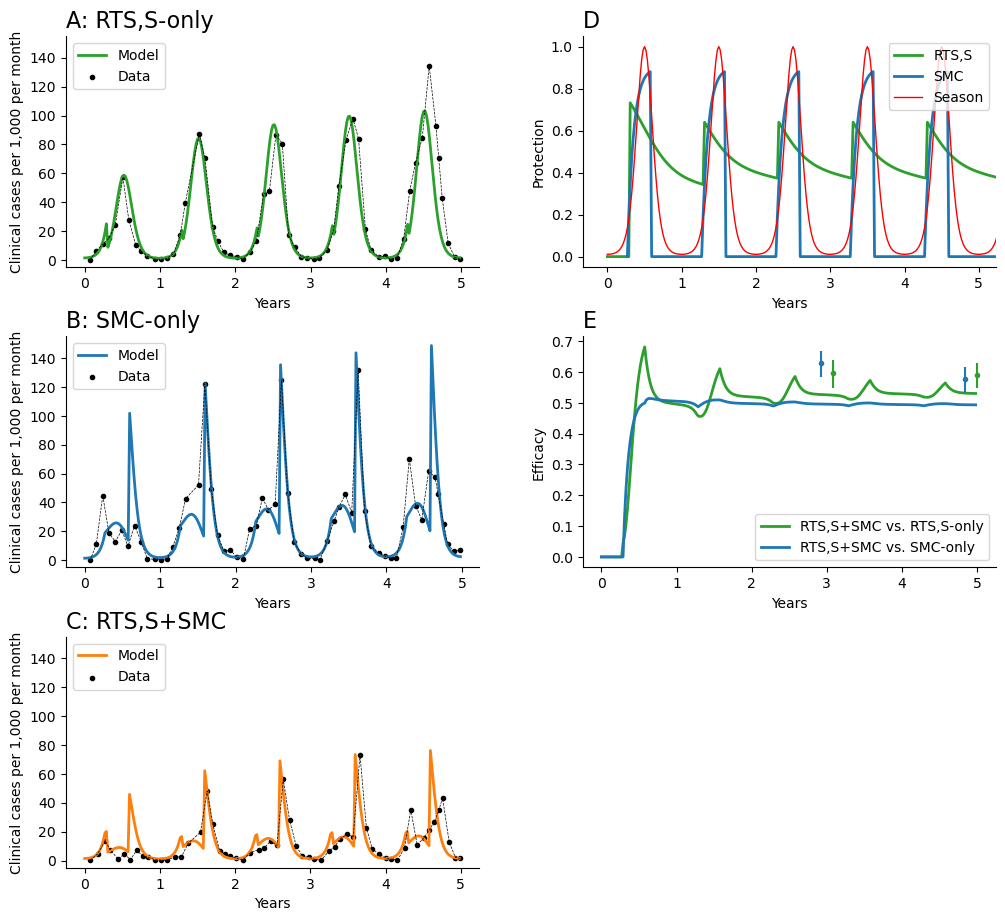

In [ ]:
#| label: fig-dicko-clinical-case-prediction
#| fig-cap: "Calibration of seasonal malaria chemoprevention parameters to trial data from @chandramohan_seasonal_2021 and @dicko_seasonal_2024. Panels A, B and C: temporal dynamics of the three trial arms; RTS,S-only, SMC-only and combined RTS,S+SMC. Circles with dashed lines: data, coloured lines: model calibration. Panel D: red: seasonal transmission intensity, green: protective effect of RTS,S on blood infection (1 represents 100% protection), blue: protective effect of SMC. Panel E: Efficacies of RTS,S+SMC relative to RTS,S-only (green) and SMC-only (blue). Circles with error bars are efficacy estimates from @dicko_seasonal_2024."

# estimates = [26, 0.1, 16, 0.24, 14, 4, 2] # use if haven't run calibration code above
fig, axs = dicko.dicko_clinical_episode_prediction(estimates, fig_xscale=2, fig_yscale=0.9)

::: {#refs}
:::